In [1]:
import scipy.io as io
data = io.loadmat('WLDataCW.mat') #import the data
print('the length:  ' + str(len(data))) #check the number of keys
print(data.keys()) #show the names of keys
print(data['__globals__'])
data_only = data["data"] #assing the data into new variable
label = data["label"] #assign the label to a new variable
print(data_only.shape) #check the dimension of the data
print(label.shape) #check the dimension of the label

the length:  5
dict_keys(['__header__', '__version__', '__globals__', 'data', 'label'])
[]
(62, 512, 360)
(1, 360)


In [2]:
import numpy as np
from scipy.signal import welch
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

# Define EEG frequency bands (in Hz)
BANDS = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 12),
    "beta": (12, 30),
    "gamma": (30, 45)
}

# EEG sampling frequency (assumed 512 Hz based on dataset shape)
fs = 512  

# Function to compute band power using Welch’s method
def compute_band_power(signal, fs, band):
    fmin, fmax = band
    freqs, psd = welch(signal, fs=fs, nperseg=256)  # Compute Power Spectral Density (PSD)
    power = np.trapz(psd[(freqs >= fmin) & (freqs <= fmax)], freqs[(freqs >= fmin) & (freqs <= fmax)])
    return power

# Reshape data: (62, 512, 360) → (360, 62, 512)
X = np.moveaxis(data_only, -1, 0)  # Shape: (360, 62, 512)

# Compute band power features
X_bandpower = np.zeros((X.shape[0], X.shape[1], len(BANDS)))  # (360, 62, 5)

for i in range(X.shape[0]):  # Iterate over samples
    for j in range(X.shape[1]):  # Iterate over channels
        for k, band in enumerate(BANDS.values()):  
            X_bandpower[i, j, k] = compute_band_power(X[i, j, :], fs, band)

# Reshape to (360, 62 * 5) = (360, 310)
X_features = X_bandpower.reshape(X.shape[0], -1)

# Normalize features
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X_features)

# Set up 5-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
folds = list(kf.split(X_normalized))

# Print dataset details
print("Data shape after preprocessing:", X_normalized.shape)  # Should be (360, 310)
print("Number of folds:", len(folds))
for i, (train_idx, test_idx) in enumerate(folds):
    print(f"Fold {i+1}: Train {len(train_idx)} samples, Test {len(test_idx)} samples")


Data shape after preprocessing: (360, 310)
Number of folds: 5
Fold 1: Train 288 samples, Test 72 samples
Fold 2: Train 288 samples, Test 72 samples
Fold 3: Train 288 samples, Test 72 samples
Fold 4: Train 288 samples, Test 72 samples
Fold 5: Train 288 samples, Test 72 samples


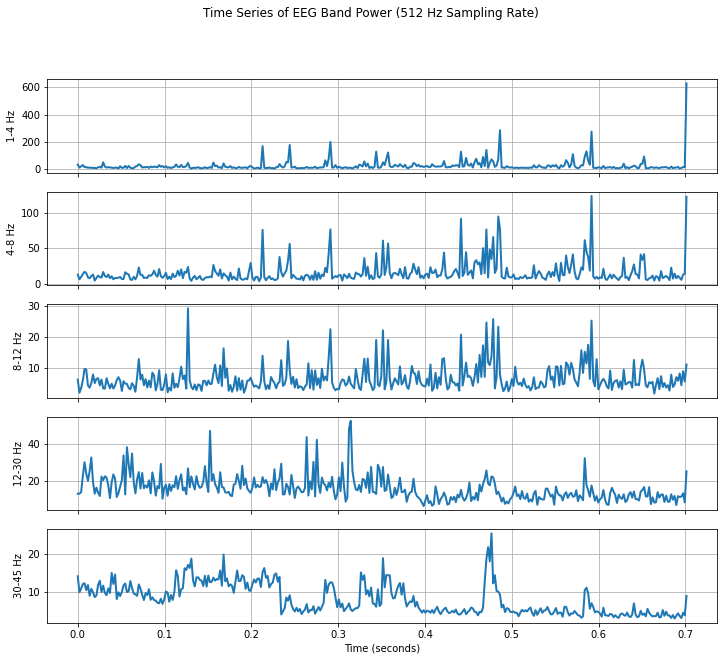

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def plot_each_band_separately(X_bandpower, band_hz, fs):
    """
    Plots separate time series graphs for each frequency band, all stacked in one figure.
    
    X_bandpower: 3D array of shape (trials, sensors, bands)
    band_hz: Dictionary of band names and their frequency ranges
    fs: Sampling frequency (512 Hz for EEG data)
    """
    num_trials, num_sensors, num_bands = X_bandpower.shape
    time = np.arange(num_trials) / fs  # Convert trials to time (seconds)

    fig, axes = plt.subplots(num_bands, 1, figsize=(12, 10), sharex=True)

    for i, (band, (fmin, fmax)) in enumerate(band_hz.items()):
        avg_bandpower = np.mean(X_bandpower[:, :, i], axis=1)  # Average across sensors
        axes[i].plot(time, avg_bandpower, linewidth=2)
        axes[i].set_ylabel(f"{fmin}-{fmax} Hz")  # Label y-axis with frequency range
        axes[i].grid(True)

    axes[-1].set_xlabel("Time (seconds)")  # Only bottom subplot gets x-axis label
    fig.suptitle("Time Series of EEG Band Power (512 Hz Sampling Rate)")
    plt.show()

# Example: Plot all bands in separate graphs within one figure
plot_each_band_separately(X_bandpower, BANDS, fs=512)


In [4]:
import numpy as np

# Ensure labels are correctly shaped
label = label.flatten()  # Flatten to shape (360,)

# Store accuracies of all folds
accuracies = []

# Define forward propagation for logistic regression
def forward_propagation(X, W, b):
    v = np.dot(X, W.T) + b  # Compute linear combination
    y_hat = 1 / (1 + np.exp(-v))  # Apply sigmoid function
    return y_hat

# Define loss function (Binary Cross-Entropy)
def loss_func(y_pred, y_true):
    epsilon = 1e-5  # Prevent log(0) issues
    loss = -np.mean(y_true * np.log(y_pred + epsilon) + (1 - y_true) * np.log(1 - y_pred + epsilon))
    return loss

# Define backward propagation for updating weights and bias
def backward_propagation(y_hat, y_true, X):
    m = X.shape[0]  # Number of samples
    error = y_hat - y_true  # Shape (m, 1)
    W_grad = (1/m) * np.dot(error.T, X)  # Compute gradient for weights, now (1, features)
    b_grad = np.mean(error)  # Compute gradient for bias
    return W_grad, b_grad

# Function to update parameters
def update(W, b, W_grad, b_grad, l_r):
    W -= l_r * W_grad  # Update weights
    b -= l_r * b_grad  # Update bias

# Perform 5-fold cross-validation training
for fold_idx, (train_idx, test_idx) in enumerate(folds):
    print(f"\nTraining on Fold {fold_idx + 1}")

    # Get training and test sets
    X_train, X_test = X_normalized[train_idx], X_normalized[test_idx]
    y_train, y_test = label[train_idx].reshape(-1, 1), label[test_idx].reshape(-1, 1)  # Ensure correct shape

    # Initialize weights and biases (re-initialized per fold)
    W_vals = np.random.randn(1, X_train.shape[1]) * 0.01  # Small random values
    b_vals = np.zeros((1, 1))  # Bias scalar
    learn_rate = 0.01  # Learning rate

    # Forward propagation
    y_hat_train = forward_propagation(X_train, W_vals, b_vals)

    # Compute loss (for reference)
    loss = loss_func(y_hat_train, y_train)
    print(f"Initial Loss: {loss:.5f}")

    # Compute gradients
    W_grad, b_grad = backward_propagation(y_hat_train, y_train, X_train)

    # Update weights and bias (only once)
    update(W_vals, b_vals, W_grad, b_grad, learn_rate)

    # Test the model
    y_test_pred = forward_propagation(X_test, W_vals, b_vals)
    y_test_pred_binary = (y_test_pred >= 0.5).astype(int)  # Convert to binary predictions

    # Calculate accuracy
    accuracy = np.mean(y_test_pred_binary == y_test) * 100
    accuracies.append(accuracy)

# Calculate and print mean accuracy
lr_mean_accuracy = np.mean(accuracies)
print(f"\nMean Accuracy across all folds: {lr_mean_accuracy:.2f}%")

np.save("X_normalized.npy", X_normalized)  # Save features
np.save("label.npy", label)  # Save labels


Training on Fold 1
Initial Loss: 0.68940

Training on Fold 2
Initial Loss: 0.73368

Training on Fold 3
Initial Loss: 0.69326

Training on Fold 4
Initial Loss: 0.72046

Training on Fold 5
Initial Loss: 0.71447

Mean Accuracy across all folds: 68.33%


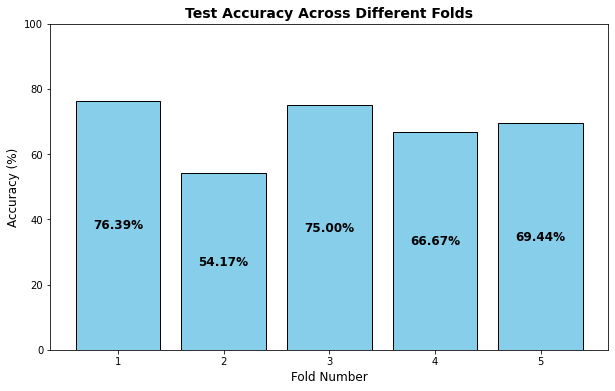

In [5]:
import matplotlib.pyplot as plt

# Convert accuracies to numpy array for calculations
fold_numbers = np.arange(1, len(accuracies) + 1)  # Fold numbers (1, 2, ..., N)

# Create the figure and bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(fold_numbers, accuracies, color='skyblue', edgecolor='black')

# Annotate bars with accuracy values in the middle
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2, 
             f"{acc:.2f}%", ha='center', va='center', fontsize=12, fontweight='bold', color='black')

# Set titles and labels
plt.title("Test Accuracy Across Different Folds", fontsize=14, fontweight='bold')
plt.xlabel("Fold Number", fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.xticks(fold_numbers)  # Ensure all folds are labeled
plt.ylim(0, 100)  # Accuracy is a percentage (0-100%)

# Show the plot
plt.show()
